In [2]:
# !pip install lightgbm shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score, brier_score_loss

# Load dữ liệu từ Buổi 2
df = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\processed_bank_data_clv.csv')

# Convert cột ngày tháng
df['created_date'] = pd.to_datetime(df['created_date'])
df['last_active_date'] = pd.to_datetime(df['last_active_date'])

print(f"Data Loaded: {df.shape}")

Data Loaded: (79949, 14)


In [5]:
# Kiểm tra và khôi phục cột balance nếu thiếu
if 'balance' not in df.columns:
    print("⚠️ Đang khôi phục cột balance từ dữ liệu gốc...")
    try:
        # Đọc lại file gốc chỉ lấy cột id và balance
        df_origin = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\bank_churn_dataset_80k.csv')
        
        # Ghép (Merge) vào dataframe hiện tại
        df = df.merge(df_origin[['id', 'balance']], on='id', how='left')
        print("✅ Đã khôi phục thành công cột balance!")
    except FileNotFoundError:
        print("❌ Lỗi: Không tìm thấy file gốc bank_churn_dataset_80k.csv")

⚠️ Đang khôi phục cột balance từ dữ liệu gốc...
✅ Đã khôi phục thành công cột balance!


In [6]:
# 1. Tái tạo Recency (Quan trọng nhất cho Churn)
snapshot_date = df['last_active_date'].max() + pd.Timedelta(days=1)
df['Recency_Days'] = (snapshot_date - df['last_active_date']).dt.days

# 2. Xử lý Categorical Features (Occupation)
# LightGBM có thể xử lý category tốt bằng cách chuyển sang dạng 'category' type
df['occupation'] = df['occupation'].astype('category')
df['Customer_Segment_RFM'] = df['Customer_Segment_RFM'].astype('category')

# 3. Target Variable
# exit: True -> 1 (Churn), False -> 0 (Stay)
df['target'] = df['exit'].astype(int)

# Chọn features đưa vào mô hình
feature_cols = [
    'Recency_Days', 'age', 'credit_sco', 'balance', 'nums_service',
    'risk_score', 'CLV_12_months', 'predicted_purchases_12weeks', # Dùng output buổi 2 làm input buổi 3
    'occupation', 'Customer_Segment_RFM'
]

X = df[feature_cols]
y = df['target']

# Chia tập Train/Test (80% Train, 20% Test)
# Stratify=y để đảm bảo tỉ lệ Churn ở 2 tập đều nhau
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Tỉ lệ Churn trong tập Train:", y_train.mean())

Tỉ lệ Churn trong tập Train: 0.18011538641942496


In [7]:
# Setup LightGBM Classifier
clf = lgb.LGBMClassifier(
    n_estimators=200,      # Số lượng cây
    learning_rate=0.05,    # Tốc độ học
    max_depth=5,           # Độ sâu cây (tránh overfitting)
    random_state=42,
    class_weight='balanced', # Quan trọng: Giúp model chú ý đến nhóm Churn (thường ít hơn nhóm Stay)
    verbose=-1             # Tắt log thừa
)

# Train model
# Lưu ý: LightGBM tự xử lý cột category (occupation), không cần One-Hot Encoding
clf.fit(X_train, y_train)

# Dự báo xác suất (Probability)
y_pred_prob = clf.predict_proba(X_test)[:, 1]

print("Đã train xong LightGBM!")

Đã train xong LightGBM!


--- Model Performance ---
ROC AUC: 0.8460 (Khả năng phân biệt Churn/Stay)
PR AUC : 0.5061 (Độ chính xác khi tìm kiếm tập Churn)
Brier Score: 0.1704 (Độ chính xác của xác suất dự báo)


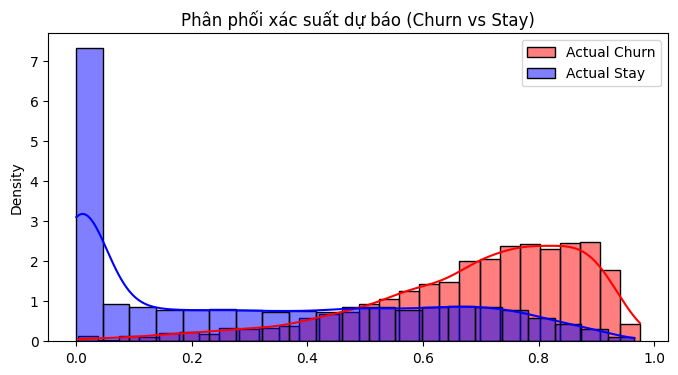

In [8]:
# 1. ROC-AUC (Càng gần 1 càng tốt)
auc = roc_auc_score(y_test, y_pred_prob)

# 2. PR-AUC (Quan trọng khi dữ liệu mất cân bằng)
pr_auc = average_precision_score(y_test, y_pred_prob)

# 3. Brier Score (Độ lệch xác suất: Càng thấp càng tốt)
# Nếu Brier Score < 0.1 là rất tốt, > 0.25 là tệ
brier = brier_score_loss(y_test, y_pred_prob)

print(f"--- Model Performance ---")
print(f"ROC AUC: {auc:.4f} (Khả năng phân biệt Churn/Stay)")
print(f"PR AUC : {pr_auc:.4f} (Độ chính xác khi tìm kiếm tập Churn)")
print(f"Brier Score: {brier:.4f} (Độ chính xác của xác suất dự báo)")

# Vẽ phân phối xác suất
plt.figure(figsize=(8, 4))
sns.histplot(y_pred_prob[y_test==1], color='red', label='Actual Churn', kde=True, stat="density", alpha=0.5)
sns.histplot(y_pred_prob[y_test==0], color='blue', label='Actual Stay', kde=True, stat="density", alpha=0.5)
plt.title('Phân phối xác suất dự báo (Churn vs Stay)')
plt.legend()
plt.show()

c:\Users\Hi\Desktop\RetentIO_Project\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


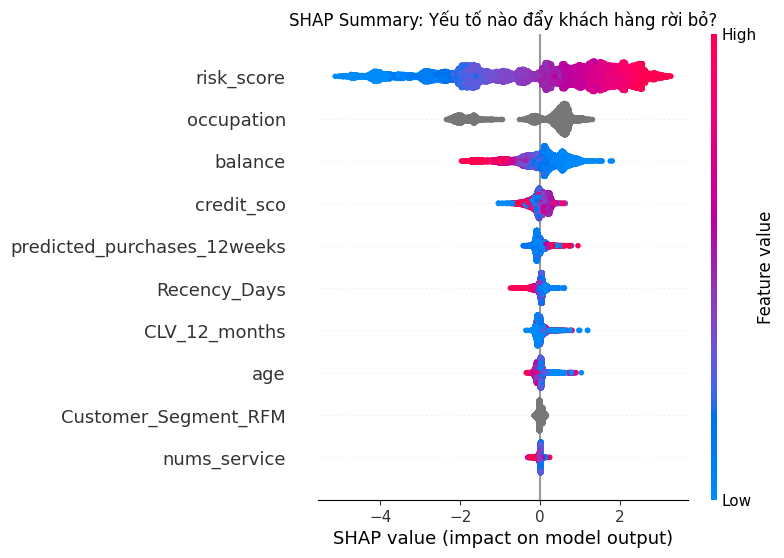

In [9]:
# Tính SHAP Values
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Lưu ý: LightGBM binary trả về list 2 array (cho class 0 và class 1).
# Ta lấy shap_values[1] là giải thích cho class 1 (Churn)
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

# 1. Summary Plot (Biểu đồ con ong)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_churn, X_test, show=False)
plt.title("SHAP Summary: Yếu tố nào đẩy khách hàng rời bỏ?")
plt.show()

# 2. Giải thích:
# - Màu ĐỎ là giá trị feature CAO, màu XANH là THẤP.
# - Nếu chấm ĐỎ nằm bên PHẢI (SHAP > 0) -> Giá trị cao làm TĂNG nguy cơ Churn.
# - Ví dụ: Nếu Recency màu đỏ nằm bên phải -> Khách lâu không quay lại thì dễ Churn (Logic đúng).
# - Nếu CLV màu đỏ nằm bên trái -> Khách giá trị cao thì ÍT Churn (Logic đúng).

In [10]:
# Dự báo cho toàn bộ dataset
df['Churn_Prob'] = clf.predict_proba(df[feature_cols])[:, 1]

# Lưu file
cols_to_save = [
    'id', 'full_name', 'created_date', 'last_active_date',
    'Customer_Segment_RFM', 'occupation',
    'CLV_12_months', 'CLV_Segment', # Kết quả buổi 2
    'Churn_Prob', 'Recency_Days', # Kết quả buổi 3
    'exit', 'age', 'balance' # Features gốc
]

df[cols_to_save].to_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\processed_bank_data_churn.csv', index=False)
print("Đã lưu file: processed_bank_data_churn.csv")

Đã lưu file: processed_bank_data_churn.csv
